# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [297]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [298]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [299]:
print()
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [300]:
print()
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [301]:
print()
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** no uso `print()` para que la tabla se vea mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [302]:
# revisar el número de filas y columnas de cada dataset
print("\n", "plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape, "\n")


 plans (2, 8)
users (4000, 8)
usage (40000, 6) 



In [303]:
print()
plans.info()# inspección de plans con .info()
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes



In [304]:
print()
users.info()# inspección de users con .info()
print()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB



In [305]:
print()
usage.info()# inspección de usage con .info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [306]:
# cantidad de nulos para users
print("\n", users[['user_id',	'first_name',	'last_name',	'age',	'city',	'reg_date',	'plan',	'churn_date']].isna().sum().sort_values(ascending=False))	# Cantidad de valores nulos)
print()
print(users[['user_id',	'first_name',	'last_name',	'age',	'city',	'reg_date',	'plan',	'churn_date']].isna().mean().sort_values(ascending=False))# Proporción de valores nulos)
print()


 churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64

churn_date    0.88350
city          0.11725
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
reg_date      0.00000
plan          0.00000
dtype: float64



In [307]:
#Creación de Pivot Table nulos para 'users'
users_cols =['user_id',	'first_name',	'last_name',	'age',	'city',	'reg_date',	'plan',	'churn_date'] #Lista de columnas de "users"
tabla_users_valores_nulos = pd.DataFrame({'nulos_users': users[users_cols].isna().sum().sort_values(ascending=False),
                                     'proporcion': users[users_cols].isna().mean().sort_values(ascending=False)})
tabla_users_valores_nulos['proporcion_%'] = (tabla_users_valores_nulos['proporcion']*100).round(2).astype(str) + '%'
tabla_users_valores_nulos = tabla_users_valores_nulos.drop(columns='proporcion')

display(tabla_users_valores_nulos)
print("users", users.shape)

,nulos_users,proporcion_%
churn_date,3534,88.35%
city,469,11.72%
user_id,0,0.0%
first_name,0,0.0%
last_name,0,0.0%
age,0,0.0%
reg_date,0,0.0%
plan,0,0.0%


users (4000, 8)


In [308]:
#Creación de Pivot Table nulos para 'usage'
usage_cols = ['id',	'user_id',	'type',	'date',	'duration',	'length'] #Lista de columnas de "usage"

tabla_usage_valores_nulos = pd.DataFrame({'nulos_usage': usage[usage_cols].isna().sum().sort_values(ascending=False),
                                     'proporcion': usage[usage_cols].isna().mean().sort_values(ascending=False)})
tabla_usage_valores_nulos['proporcion_%'] = (tabla_usage_valores_nulos['proporcion']*100).round(2).astype(str) + '%'
tabla_usage_valores_nulos = tabla_usage_valores_nulos.drop(columns='proporcion')
display(tabla_usage_valores_nulos)
print("usage", usage.shape, "\n")

,nulos_usage,proporcion_%
duration,22076,55.19%
length,17896,44.74%
date,50,0.12%
id,0,0.0%
user_id,0,0.0%
type,0,0.0%


usage (40000, 6) 



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos: users**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? Son dos columnas:
  -La columna 'churn_date' tiene 88.35% de filas vacías, significando usuarios activos, mientras que el 11.65% de los usuarios se han dado de baja. Por tanto, se ignora, dejando los datos originales.
  -La columna 'city' tiene 11.72% de filas vacías, por lo que se investigará para imputar o dejarlas como nulos.
- Indica qué harías: ¿imputar, eliminar, ignorar?
  -La columna 'churn_date' se ignorará.
  -La columna 'city' se imputará.

---

**Valores nulos: usage**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? Para esta tabla una fila corresponde el registro de la llamada ('duration') o el registro del mensaje ('length'), por ende, son dos columnas:
  -La columna 'duration' tiene un 55.19% de filas vacías, el resto comprende al registro de los mensajes y netamente a filas vacías.
  -La columna 'length' tiene 44.74% de filas vacías, el resto comprende al registro de las llamadas y netamente a filas vacías.

Total de filas vacías = 100% - 'duration' - 'length'

Total de filas vacías = 0.07%


- Indica qué harías: ¿imputar, eliminar, ignorar?
  -La columna 'duration' se imputará.
  -La columna 'length' se imputará.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [309]:
print( "Obtención de la mediana\n\n", users.median(),"\n\n")
print("Resumen estadístico\n")
users.describe().round(0) # explorar columnas numéricas de users

Obtención de la mediana

 user_id    11999.5
age           47.0
dtype: float64 


Resumen estadístico



,user_id,age
count,4000.0,4000.0
mean,12000.0,34.0
std,1155.0,123.0
min,10000.0,-999.0
25%,11000.0,32.0
50%,12000.0,47.0
75%,12999.0,63.0
max,13999.0,79.0


- La columna `user_id` no se detectan sentinels, la mediana y la desviación estándar son similares, distribución normal.
- La columna `age` en el valor mínimo se detecta sentinel, por lo que se tiene que imputar. En cuanto a la desviación estándar se ve afectado, por lo que al imputarlo se volvera a calcular la std.

In [310]:
print( "Obtención de la mediana\n\n", usage.median(),"\n\n")
print("Resumen estadístico\n")
usage.describe().round(2) # explorar columnas numéricas de usage

Obtención de la mediana

 id          20000.5
user_id     12013.0
duration        3.5
length         50.0
dtype: float64 


Resumen estadístico



,id,user_id,duration,length
count,40000.00,40000.00,17924.00,22104.00
mean,20000.50,12002.41,5.20,52.13
std,11547.15,1157.28,6.84,56.61
min,1.00,10000.00,0.00,0.00
25%,10000.75,10996.00,1.44,37.00
50%,20000.50,12013.00,3.50,50.00
75%,30000.25,13005.00,6.99,64.00
max,40000.00,13999.00,120.00,1490.00


- Las columnas `id` y `user_id` no hacen falta datos, comparando la std con la mediana, ambos valores son similares, distribución normal. Para el `id`, el min y el máx corresponden a las secuencias. Para el `user_id` el min y el máx son iguales con respecto a la tabla users.
- Las columnas `duration` y `length` no presentan sentinels, los valores de la std y la mediana son similares, distribución normal.

In [311]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene 7 valores únicos, Bogotá está en el top con una frecuencia de 808. Recordando del primer análisis tiene valores nulos siendo el 11.72% de los 4000 registros.
- La columna `plan` tiene dos valores únicos, no presenta valores nulos ya que son 4000 registros, Básico está en el top con una frecuencia de 2595 representando el 64.875% del total de datos.

In [312]:
# explorar columna categórica de usage
columnas_usage = ['type']
usage[columnas_usage].describe() # completa el código

,type
count,40000
unique,2
top,text
freq,22092


- La columna `type` tiene dos valores únicos, text está en el top con una frecuencia de 22092 representando el 55.23% del total de datos.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? En dataset users columna age. 
- ¿Qué acción tomarías? Si es un único valor, descartarlo.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [313]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [314]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [315]:
# Revisar los años presentes en `reg_date` de users
users_year_counts = users['reg_date'].dt.year.dropna().astype(int).value_counts().sort_index()
total_users_year_counts = users_year_counts.sum()
print()
print("Año        Conteo     Pct(%)")

for year, count in users_year_counts.items():
    percentage = (count/total_users_year_counts) * 100
    print(f"{year}      {count:>6}      {percentage:>5.2f}")
print()


Año        Conteo     Pct(%)
2022        1314      32.85
2023        1316      32.90
2024        1330      33.25
2026          40       1.00



En `reg_date` se encuentra registrado el año 2026, cuando el alcance del estudio es hasta 2024. Son 40 datos siendo el 1% del total de datos

In [316]:
# Revisar los años presentes en `date` de usage
usage_year_counts = usage['date'].dt.year.dropna().astype(int).value_counts().sort_index()
total_usage_year_counts = usage['id'].count() #Se usa la columna `id` donde se obtiene el número de total de datos, ya que la columna `date` contiene 39950, está incompleto.

print()
print("Año       Conteo     Pct(%)")

for year, count in usage_year_counts.items():
    percentage = ((count/total_usage_year_counts)*100)
    print(f"{year}      {count}      {percentage}")
print()


Año       Conteo     Pct(%)
2024      39950      99.875



En `date` solo tiene registros del año 2024, le faltan 50 datos representando el 0.225%.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? En la tabla `users` en la columna de `date` aparece el año 2026, lo cual no es posible ya que la información está recabado hasta el 2024. #(años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas? Los voy a revisar si aplica imputación o descarte.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [317]:
#Conteo de datos con valor de -999 en tabla `users` columna `age`
print()
print("Conteo de valores -999 antes de remplazar: ", users['age'].isin([-999]).sum())
print()
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
users['age'] = users['age'].astype('Int64')
# Verificar cambios
print("\nResumen estadístico después de remplazar -999:\n")
users['age'].describe().astype(int) #REVISAR ESTA PARTE YA QUE AL CONVERTIRLO EN NÚMERO ENTERO, EN EL CONTEO DE `-999` QUE ES 55, SE VUELVE 0


Conteo de valores -999 antes de remplazar:  55


Resumen estadístico después de remplazar -999:



count    4000
mean       48
std        17
min        18
25%        33
50%        47
75%        63
max        79
Name: age, dtype: int64

In [318]:
#Conteo de valores "?" en tabla `users` columna `city`
print("\nConteo de valores ? antes de remplazar: ", users['city'].isin(["?"]).sum())

# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA) 

# Verificar cambios
print("\nResumen estadístico después de remplazar ?:\n")
users['city'].describe()


Conteo de valores ? antes de remplazar:  96

Resumen estadístico después de remplazar ?:



count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [319]:
# Descripción antes de remplazar 2026 en tabla `users` columna `reg_date`
print("\nAnálisis estadístico de la columna creada `reg_year` extrayendo el año de la columna `reg_date`\n" )

#Creación de la columna `reg_year`
users['reg_year'] = users['reg_date'].dt.year

print( "Obtención de la mediana:\n", users['reg_year'].median().astype(int))

print("\nResumen estadístico antes de remplazar el año 2026 de la columna creada `reg_year`\n")

print(users['reg_year'].describe().astype(int),"\n")

#print("Conteo de valores 2026 antes de remplazar: ", users['reg_year'].isin([2026]).sum(), "\n" )
print("Conteo de valores 2026 antes de remplazar: ", (users['reg_date'].dt.year == 2026).sum(), "\n" )

# Marcar fechas futuras como NA para reg_date
print("Resumen estadístico después de remplazar 2026:\n")
users['reg_year'] = users['reg_year'].replace(2026, pd.NA)
users['reg_year'] = pd.to_numeric(users['reg_year'], errors='coerce')
users['reg_year'] = users['reg_year'].astype('Int64')

print(users['reg_year'].describe().astype(int),"\n")

# Verificar cambios



Análisis estadístico de la columna creada `reg_year` extrayendo el año de la columna `reg_date`

Obtención de la mediana:
 2023

Resumen estadístico antes de remplazar el año 2026 de la columna creada `reg_year`

count    4000
mean     2023
std         0
min      2022
25%      2022
50%      2023
75%      2024
max      2026
Name: reg_year, dtype: int64 

Conteo de valores 2026 antes de remplazar:  40 

Resumen estadístico después de remplazar 2026:

count    3960
mean     2023
std         0
min      2022
25%      2022
50%      2023
75%      2024
max      2024
Name: reg_year, dtype: int64 



### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [320]:
# Verificación MAR en usage (Missing At Random) para duration
missing_usage_duration_by_type = (usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)*100).round(3)
print(missing_usage_duration_by_type)

type
text    99.928
call     0.000
Name: duration, dtype: float64


In [321]:
# Verificación MAR en usage (Missing At Random) para length
missing_usage_length_by_type = (usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)*100).round(3)
print(missing_usage_length_by_type)

type
call    99.933
text     0.000
Name: length, dtype: float64


---------------------------------------------
Diagnóstico de nulos en `duration` y `length`:

De acuerdo al cálculo realizado, se observa que para ambas columnas `duration` y `length` son dependientes de la columna `type`, ya que el registro depende de si fue llamada o fue mensaje de texto.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [322]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby(['user_id']).agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
})

# observar resultado
usage_agg.head(10)

,is_text,is_call,duration
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74
10003,11,3,8.99
10004,4,3,8.01
10005,5,7,44.97
10006,3,5,28.39
10007,3,5,30.23
10008,5,5,28.85


In [323]:
# Renombrar columnas
usage_agg.columns = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']
#usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes','is_call': 'cant_llamadas','duration': 'cant_minutos_llamadas'})
# observar resultado
usage_agg.head(10)

,cant_mensajes,cant_llamadas,cant_minutos_llamadas
user_id,,,
10000,7,3,23.70
10001,5,10,33.18
10002,5,2,10.74
10003,11,3,8.99
10004,4,3,8.01
10005,5,7,44.97
10006,3,5,28.39
10007,3,5,30.23
10008,5,5,28.85


In [324]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on = 'user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,2022,7,3,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,2022,5,10,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2022,5,2,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,2022,11,3,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,2022,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [325]:
# Resumen estadístico de las columnas numéricas
user_profile_cols_num = ['age', 'reg_year', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

#Obtener mediana de varias columnas de user_profile: método directo
user_profile_medianas = user_profile[user_profile_cols_num].median()
print("\nColumna                 Mediana")
print(user_profile_medianas.astype(int))
print()

#Obtener mediana de varias columnas de user_profile: método DataFrame con bucle for
#resultados = []
#for cols in user_profile_cols_num:
    #mediana = user_profile[cols].median().astype(int)
    #resultados.append({'columna': cols, 'mediana': mediana })
#user_profile_medianas = pd.DataFrame(resultados)
#print( '\n', user_profile_medianas, "\n")

#Obtener mediana de varias columnas de user_profile: método diccionario con bucle for
#medianas = {}
#for cols in user_profile_cols_num:
    #medianas[cols] = user_profile[cols].median().astype(int)
#print('\nMedianas por columna: \n')
#for cols, valor in medianas.items():
    #print(f"{cols}: {valor}")
#print()

#Obtener mediana de varias columnas de user_profile: método bucle for
#print("Columna                 Mediana")
#for cols in user_profile_cols_num:
    #mediana = user_profile[cols].median().astype(int)
    #print(f"{cols:<25} {mediana:>5}")
#print()

user_profile[['age', 'reg_year', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']].describe().round(2)


Columna                 Mediana
age                        47
reg_year                 2023
cant_mensajes               5
cant_llamadas               4
cant_minutos_llamadas      19
dtype: int64



,age,reg_year,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,3999.00,3959.00,3999.00,3999.00,3999.00
mean,48.12,2023.00,5.52,4.48,23.32
std,17.69,0.82,2.36,2.14,18.17
min,18.00,2022.00,0.00,0.00,0.00
25%,33.00,2022.00,4.00,3.00,11.12
50%,47.00,2023.00,5.00,4.00,19.78
75%,63.00,2024.00,7.00,6.00,31.42
max,79.00,2024.00,17.00,15.00,155.69


In [346]:
# Distribución porcentual del tipo de plan
print("\nDistribución del tipo de plan\n")
print("plan       porcentage(%)")
print((user_profile.plan.value_counts(normalize=True)*100).round(2), "\n")


# Distribución porcentual del tipo de plan por `age`





Distribución del tipo de plan

plan       porcentage(%)
Basico     64.87
Premium    35.13
Name: plan, dtype: float64 



---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

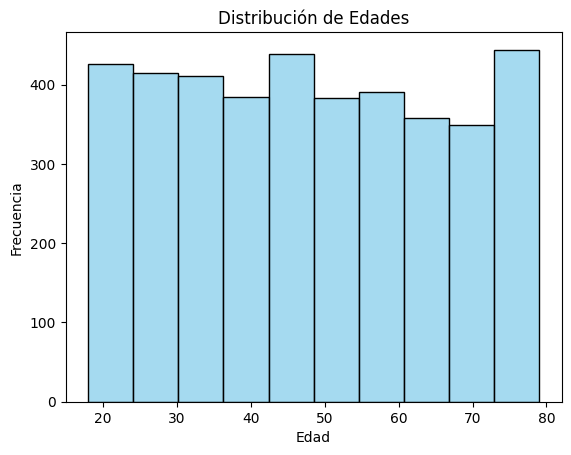

In [327]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile.age, bins = 10, color = 'skyblue')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades')
plt.show()

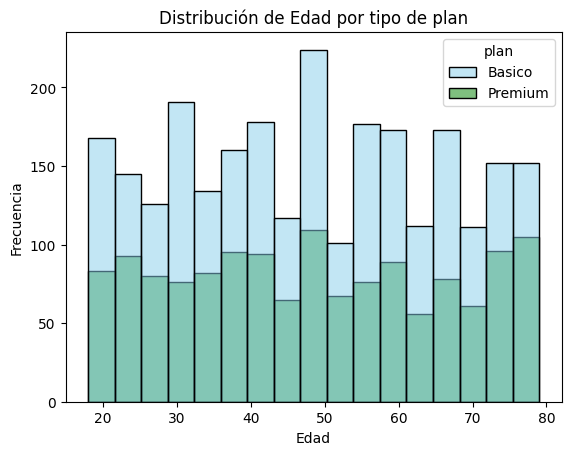

In [328]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x = 'age', hue = 'plan', palette = ['skyblue', 'green'])

plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edad por tipo de plan')

plt.show()

💡Insights: 
- Distribución se observa que es `normal`.
- Tanto en `plan``premium`como `basico` se observa que son más los usuarios con alrededor de 50 años.

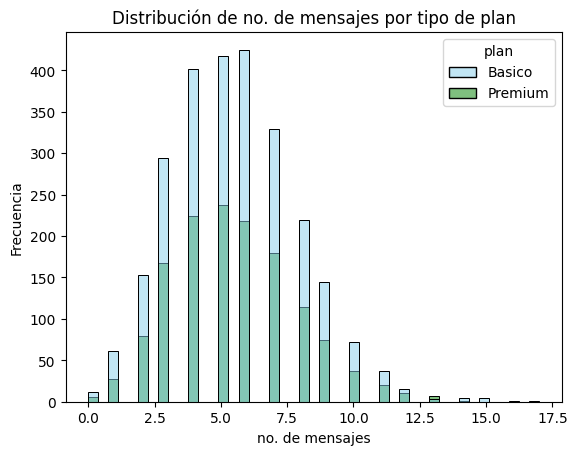

In [331]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x = 'cant_mensajes', hue = 'plan', palette = ['skyblue', 'green'])

plt.xlabel('no. de mensajes')
plt.ylabel('Frecuencia')
plt.title('Distribución de no. de mensajes por tipo de plan')

plt.show()

💡Insights: 
- Distribución se observa sesgada a la derecha.

In [ ]:
# Histograma para visualizar la cant_llamadas


💡Insights: 
- Distribución ...

In [ ]:
# Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [ ]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for

💡Insights: 
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [...]



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso


In [ ]:
# verificar cambios
user_profile.head()

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad


In [ ]:
# verificar cambios
user_profile.head()

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(...)

plt.show()

In [ ]:
# Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc 


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`